# 03 _ Hyperparameter Tuning (Attempt)

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import product

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

DATA_DIR = Path("../data")
MODEL_DIR = Path("../models")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [5]:
# Load data (same as notebook 02)
config = json.loads((DATA_DIR / "config.json").read_text())
selected_features = config["selected_features"]

df = pd.read_csv(DATA_DIR / "df.csv")
df["t_win"] = df.round_winner.astype("category").cat.codes

X = df[selected_features]
y = df["t_win"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train.values, test_size=0.15, random_state=42
)

# tensors
X_tr_t = torch.FloatTensor(X_tr).to(device)
y_tr_t = torch.FloatTensor(y_tr).to(device)
X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.FloatTensor(y_val).to(device)
X_test_t = torch.FloatTensor(X_test_scaled).to(device)
y_test_t = torch.FloatTensor(y_test.values).to(device)

n_features = X_tr.shape[1]
print(f"Ready — {n_features} features, {len(X_tr)} train, {len(X_val)} val, {len(X_test)} test")

Ready — 20 features, 83238 train, 14690 val, 24482 test


## Random Forest 

GridSearchCV from Tutorial, i need to look into this more and understand the internals

In [8]:
param_grid = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
}

rf_grid = GridSearchCV( # auto gets the best one
    RandomForestClassifier(n_jobs=-1, random_state=42),
    param_grid,
    cv=3,
    scoring="accuracy",
    verbose=1,
    n_jobs=-1,
)
rf_grid.fit(X_train_scaled, y_train)

print(f"\nBest params: {rf_grid.best_params_}")
print(f"Best CV accuracy: {rf_grid.best_score_:.4f}")
print(f"Test accuracy: {rf_grid.best_estimator_.score(X_test_scaled, y_test):.4f}")

Fitting 3 folds for each of 48 candidates, totalling 144 fits


/Users/henry/Desktop/homework/ml/mtec345-homework/henry-elkington/midterm/research/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best params: {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 500}
Best CV accuracy: 0.8108
Test accuracy: 0.8315


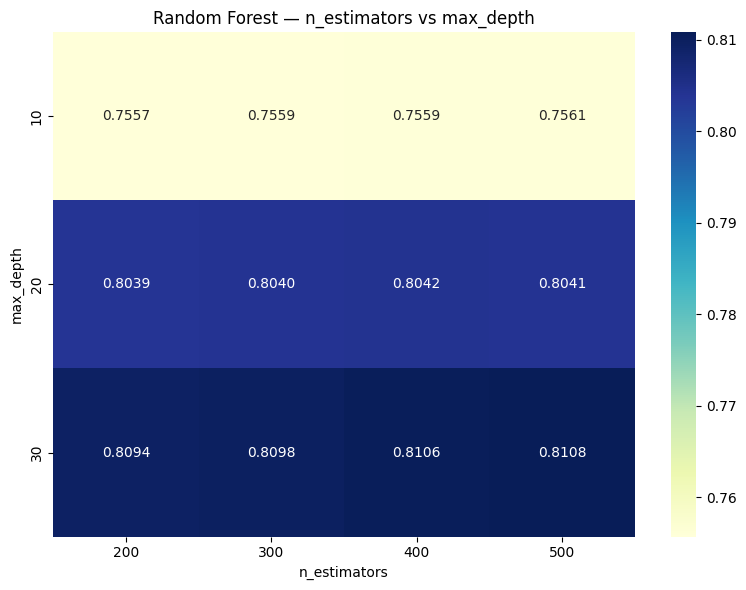

In [9]:
# Heatmap: n_estimators vs max_depth
rf_results = pd.DataFrame(rf_grid.cv_results_)

# Pivot for heatmap — average over min_samples_split
pivot = rf_results.pivot_table(
    values="mean_test_score",
    index="param_max_depth",
    columns="param_n_estimators",
    aggfunc="max",
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlGnBu", ax=ax)
ax.set_title("Random Forest — n_estimators vs max_depth")
ax.set_ylabel("max_depth")
ax.set_xlabel("n_estimators")
plt.tight_layout()
plt.show()

## MLP Hidden Size + Learning Rate Sweep

In [10]:
class MLP(nn.Module):
    def __init__(self, n_features, hidden=128, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def quick_train(model, X_tr_t, y_tr_t, X_val_t, y_val_t, epochs=40, patience=7, lr=1e-3, batch_size=256):
    """Quick training loop, returns best val accuracy."""
    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    best_val_loss = float("inf")
    wait = 0
    best_acc = 0

    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t).item()
            val_acc = ((val_pred > 0.5).float() == y_val_t).float().mean().item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_acc = val_acc
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    return best_acc

In [11]:
hidden_sizes = [64, 128, 256]
learning_rates = [1e-4, 5e-4, 1e-3, 5e-3]

mlp_results = []
for hs, lr in product(hidden_sizes, learning_rates):
    model = MLP(n_features, hidden=hs).to(device)
    acc = quick_train(model, X_tr_t, y_tr_t, X_val_t, y_val_t, lr=lr)
    mlp_results.append({"hidden": hs, "lr": lr, "val_acc": acc})
    print(f"  hidden={hs:3d}  lr={lr:.4f}  val_acc={acc:.4f}")

mlp_df = pd.DataFrame(mlp_results)
best = mlp_df.loc[mlp_df.val_acc.idxmax()]
print(f"\nBest MLP: hidden={int(best.hidden)}, lr={best.lr}, val_acc={best.val_acc:.4f}")

  hidden= 64  lr=0.0001  val_acc=0.7517
  hidden= 64  lr=0.0005  val_acc=0.7541
  hidden= 64  lr=0.0010  val_acc=0.7531
  hidden= 64  lr=0.0050  val_acc=0.7542
  hidden=128  lr=0.0001  val_acc=0.7542
  hidden=128  lr=0.0005  val_acc=0.7562
  hidden=128  lr=0.0010  val_acc=0.7534
  hidden=128  lr=0.0050  val_acc=0.7530
  hidden=256  lr=0.0001  val_acc=0.7551
  hidden=256  lr=0.0005  val_acc=0.7578
  hidden=256  lr=0.0010  val_acc=0.7573
  hidden=256  lr=0.0050  val_acc=0.7539

Best MLP: hidden=256, lr=0.0005, val_acc=0.7578


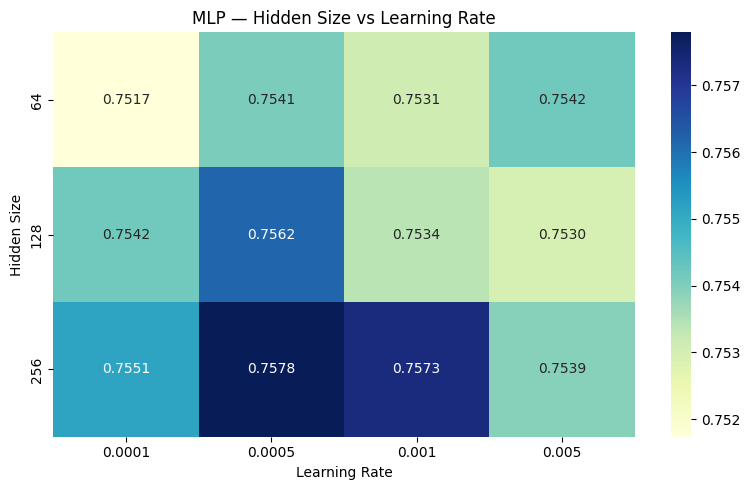

In [12]:
# Heatmap
pivot = mlp_df.pivot(index="hidden", columns="lr", values="val_acc")

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlGnBu", ax=ax)
ax.set_title("MLP — Hidden Size vs Learning Rate")
ax.set_ylabel("Hidden Size")
ax.set_xlabel("Learning Rate")
plt.tight_layout()
plt.show()

## GRU Hidden Size & Learning Rate Sweep

In [13]:
class GRUModel(nn.Module):
    def __init__(self, n_features, hidden=64, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(n_features, hidden, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        x = x.unsqueeze(1)
        out, _ = self.gru(x)
        return torch.sigmoid(self.fc(out[:, -1, :])).squeeze(-1)


gru_results = []
for hs, lr in product([32, 64, 128], [1e-4, 5e-4, 1e-3, 5e-3]):
    model = GRUModel(n_features, hidden=hs).to(device)
    acc = quick_train(model, X_tr_t, y_tr_t, X_val_t, y_val_t, lr=lr)
    gru_results.append({"hidden": hs, "lr": lr, "val_acc": acc})
    print(f"  hidden={hs:3d}  lr={lr:.4f}  val_acc={acc:.4f}")

gru_df = pd.DataFrame(gru_results)
best = gru_df.loc[gru_df.val_acc.idxmax()]
print(f"\nBest GRU: hidden={int(best.hidden)}, lr={best.lr}, val_acc={best.val_acc:.4f}")

  hidden= 32  lr=0.0001  val_acc=0.7472
  hidden= 32  lr=0.0005  val_acc=0.7522
  hidden= 32  lr=0.0010  val_acc=0.7519
  hidden= 32  lr=0.0050  val_acc=0.7537
  hidden= 64  lr=0.0001  val_acc=0.7483
  hidden= 64  lr=0.0005  val_acc=0.7521
  hidden= 64  lr=0.0010  val_acc=0.7518
  hidden= 64  lr=0.0050  val_acc=0.7542
  hidden=128  lr=0.0001  val_acc=0.7497
  hidden=128  lr=0.0005  val_acc=0.7517
  hidden=128  lr=0.0010  val_acc=0.7531
  hidden=128  lr=0.0050  val_acc=0.7512

Best GRU: hidden=64, lr=0.005, val_acc=0.7542


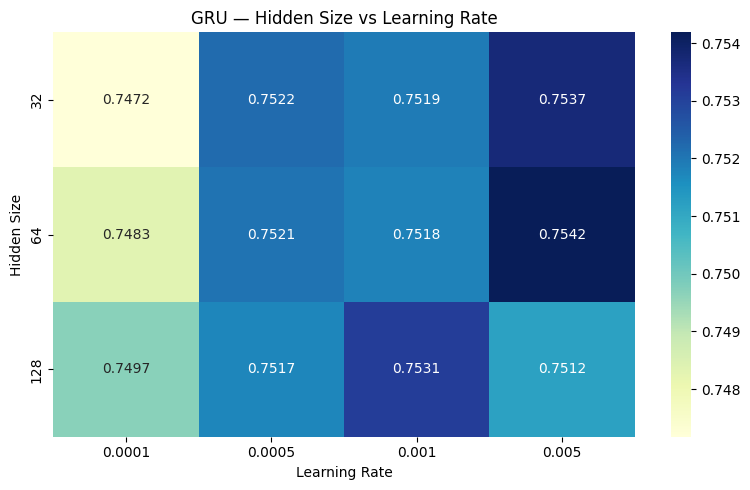

In [14]:
pivot = gru_df.pivot(index="hidden", columns="lr", values="val_acc")

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlGnBu", ax=ax)
ax.set_title("GRU — Hidden Size vs Learning Rate")
ax.set_ylabel("Hidden Size")
ax.set_xlabel("Learning Rate")
plt.tight_layout()
plt.show()

## LSTM Hidden Size and Learning Rate Sweep

In [15]:
class LSTMModel(nn.Module):
    def __init__(self, n_features, hidden=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        x = x.unsqueeze(1)
        out, _ = self.lstm(x)
        return torch.sigmoid(self.fc(out[:, -1, :])).squeeze(-1)


lstm_results = []
for hs, lr in product([32, 64, 128], [1e-4, 5e-4, 1e-3, 5e-3]):
    model = LSTMModel(n_features, hidden=hs).to(device)
    acc = quick_train(model, X_tr_t, y_tr_t, X_val_t, y_val_t, lr=lr)
    lstm_results.append({"hidden": hs, "lr": lr, "val_acc": acc})
    print(f"  hidden={hs:3d}  lr={lr:.4f}  val_acc={acc:.4f}")

lstm_df = pd.DataFrame(lstm_results)
best = lstm_df.loc[lstm_df.val_acc.idxmax()]
print(f"\nBest LSTM: hidden={int(best.hidden)}, lr={best.lr}, val_acc={best.val_acc:.4f}")

  hidden= 32  lr=0.0001  val_acc=0.7498
  hidden= 32  lr=0.0005  val_acc=0.7503
  hidden= 32  lr=0.0010  val_acc=0.7533
  hidden= 32  lr=0.0050  val_acc=0.7500
  hidden= 64  lr=0.0001  val_acc=0.7502
  hidden= 64  lr=0.0005  val_acc=0.7492
  hidden= 64  lr=0.0010  val_acc=0.7529
  hidden= 64  lr=0.0050  val_acc=0.7560
  hidden=128  lr=0.0001  val_acc=0.7502
  hidden=128  lr=0.0005  val_acc=0.7519
  hidden=128  lr=0.0010  val_acc=0.7532
  hidden=128  lr=0.0050  val_acc=0.7548

Best LSTM: hidden=64, lr=0.005, val_acc=0.7560


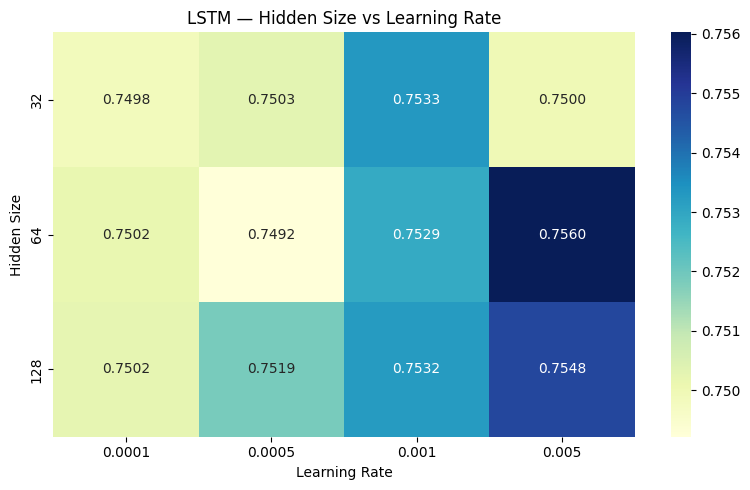

In [16]:
pivot = lstm_df.pivot(index="hidden", columns="lr", values="val_acc")

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlGnBu", ax=ax)
ax.set_title("LSTM — Hidden Size vs Learning Rate")
ax.set_ylabel("Hidden Size")
ax.set_xlabel("Learning Rate")
plt.tight_layout()
plt.show()

## Summary of Best Hyperparameters

In [17]:
# Collect best results
tuning_summary = {
    "Random Forest": {
        "best_params": rf_grid.best_params_,
        "best_cv_acc": rf_grid.best_score_,
        "test_acc": rf_grid.best_estimator_.score(X_test_scaled, y_test),
    },
    "MLP": {
        "best_params": {"hidden": int(mlp_df.loc[mlp_df.val_acc.idxmax(), "hidden"]),
                        "lr": float(mlp_df.loc[mlp_df.val_acc.idxmax(), "lr"])},
        "best_val_acc": float(mlp_df.val_acc.max()),
    },
    "GRU": {
        "best_params": {"hidden": int(gru_df.loc[gru_df.val_acc.idxmax(), "hidden"]),
                        "lr": float(gru_df.loc[gru_df.val_acc.idxmax(), "lr"])},
        "best_val_acc": float(gru_df.val_acc.max()),
    },
    "LSTM": {
        "best_params": {"hidden": int(lstm_df.loc[lstm_df.val_acc.idxmax(), "hidden"]),
                        "lr": float(lstm_df.loc[lstm_df.val_acc.idxmax(), "lr"])},
        "best_val_acc": float(lstm_df.val_acc.max()),
    },
}

(DATA_DIR / "tuning_results.json").write_text(json.dumps(tuning_summary, indent=2, default=str))

for name, info in tuning_summary.items():
    print(f"{name}:")
    for k, v in info.items():
        print(f"  {k}: {v}")
    print()

Random Forest:
  best_params: {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 500}
  best_cv_acc: 0.8108201960575455
  test_acc: 0.8315088636549302

MLP:
  best_params: {'hidden': 256, 'lr': 0.0005}
  best_val_acc: 0.7577944397926331

GRU:
  best_params: {'hidden': 64, 'lr': 0.005}
  best_val_acc: 0.7541865110397339

LSTM:
  best_params: {'hidden': 64, 'lr': 0.005}
  best_val_acc: 0.7560244798660278

